In [2]:
! pip install -q -U git+https://github.com/google-research/dinosaur --ignore-requires-python

  error: subprocess-exited-with-error
  
  × git clone --filter=blob:none --quiet https://github.com/google-research/dinosaur /tmp/pip-req-build-msp0ta3j did not run successfully.
  │ exit code: 128
  ╰─> [1 lines of output]
      致命错误：无法访问 'https://github.com/google-research/dinosaur/'：Failed to connect to github.com port 443 after 130700 ms: Could not connect to server
      [end of output]
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
error: subprocess-exited-with-error

× git clone --filter=blob:none --quiet https://github.com/google-research/dinosaur /tmp/pip-req-build-msp0ta3j did not run successfully.
│ exit code: 128
╰─> See above for output.

note: This error originates from a subprocess, and is likely not a problem with pip.


## 该代码的内容概述

1. 设置计算区域，读取初始状态当作稳态
2. 读取初始状态的各个变量
3. 将初始状态的各个物理量转换单位后进行可视化绘图(在经度lon=0的区域, 画变量关于纬度和高度的变化)

************************

4. 定义时间推进函数
5. 使用时间推进函数对稳态进行 时间推进
6. 处理计算结果为易读取的变量，
7. 读取变量并画图

**********************

8. 定义扰动
9. 定义非稳态 = 稳态 + 扰动
10. 对非稳态进行 时间推进
11. 处理计算结果为易读取的变量
12. 读取变量并画图

In [1]:
import functools
import dinosaur
import jax
import numpy as np
import matplotlib.pyplot as plt
import xarray

This notebook uses dinosaur to run the baroclinic test case from [1]. By default we use T42 grid with 24 layers. For more accurate agreement consider using higher resolution (e.g. T85 and 32 model levels).
We recommend using a GPU runtime for this notebook.

[1]:
Jablonowski, C., & Williamson, D. L. (2006). A baroclinic instability test case for atmospheric model dynamical cores. Quarterly Journal of the Royal Meteorological Society: A journal of the atmospheric sciences, applied meteorology and physical oceanography, 132(621C), 2943-2975.

# Atmosphere at rest test

In [2]:
units = dinosaur.scales.units
layers = 24  # 24层
grid = dinosaur.spherical_harmonic.Grid.T42()
vertical_grid = dinosaur.sigma_coordinates.SigmaCoordinates.equidistant(layers)
coords = dinosaur.coordinate_systems.CoordinateSystem(grid, vertical_grid)
physics_specs = dinosaur.primitive_equations.PrimitiveEquationsSpecs.from_si()

initial_state_fn, aux_features = dinosaur.primitive_equations_states.steady_state_jw(
    coords, physics_specs)
steady_state = initial_state_fn()  # 定义稳态时的情况为初始条件，之后非稳态就是steady_state + 扰动
ref_temps = aux_features[dinosaur.xarray_utils.REF_TEMP_KEY]
orography = dinosaur.primitive_equations.truncated_modal_orography(
    aux_features[dinosaur.xarray_utils.OROGRAPHY], coords)


def dimensionalize(x: xarray.DataArray, unit: units.Unit) -> xarray.DataArray:
  """Dimensionalizes `xarray.DataArray`s."""
  dimensionalize = functools.partial(physics_specs.dimensionalize, unit=unit)
  return xarray.apply_ufunc(dimensionalize, x)

2025-11-13 10:31:00.933591: W external/xla/xla/service/gpu/nvptx_compiler.cc:760] The NVIDIA driver's CUDA version is 12.2 which is older than the ptxas CUDA version (12.9.86). Because the driver is older than the ptxas version, XLA is disabling parallel compilation, which may slow down compilation. You should update your NVIDIA driver or use the NVIDIA-provided CUDA forward compatibility packages.


## Visualization of the initial state 
## 可视化初始状态的各个变量
以经度lon=0为例

各代码单元格都是
1. 读取一个初始状态中的变量
2. 转换单位
3. 经度设置为0，绘制变量与纬度与高度的关系


In [3]:
# 读取初始状态为initial_state_ds
steady_state_dict, _ = dinosaur.pytree_utils.as_dict(steady_state)
u, v = dinosaur.spherical_harmonic.vor_div_to_uv_nodal(
    grid, steady_state.vorticity, steady_state.divergence)
steady_state_dict.update({'u': u, 'v': v, 'z_surf': orography})
nodal_steady_state_fields = dinosaur.coordinate_systems.maybe_to_nodal(
    steady_state_dict, coords=coords)
initial_state_ds = dinosaur.xarray_utils.data_to_xarray(
    nodal_steady_state_fields, coords=coords, times=None)

temperature = dinosaur.xarray_utils.temperature_variation_to_absolute(
    initial_state_ds.temperature_variation.data, ref_temps)
initial_state_ds = initial_state_ds.assign(
    temperature=(initial_state_ds.temperature_variation.dims, temperature))

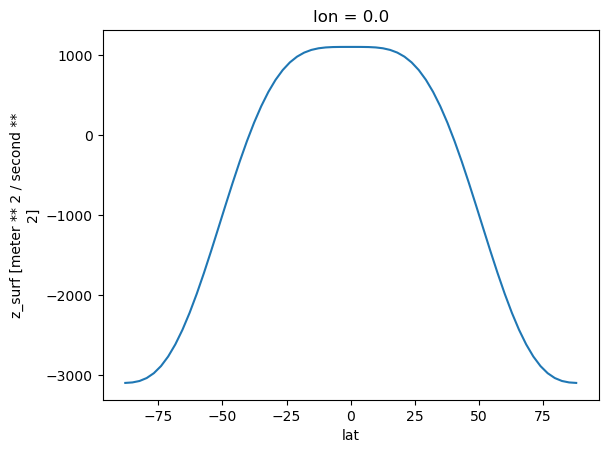

In [4]:
# Surface geopotential vizualization
# 绘制经度为0时, 即本初子午线的(即地球仪上竖着的0度的位置) 地表位势 随 纬度(上下比中间的角度) 变化的曲线
phi = initial_state_ds['z_surf'] * physics_specs.g
phi_si = dimensionalize(phi, units.m ** 2 / units.s ** 2)
phi_si.isel(lon=0).plot(x='lat');
plt.show()

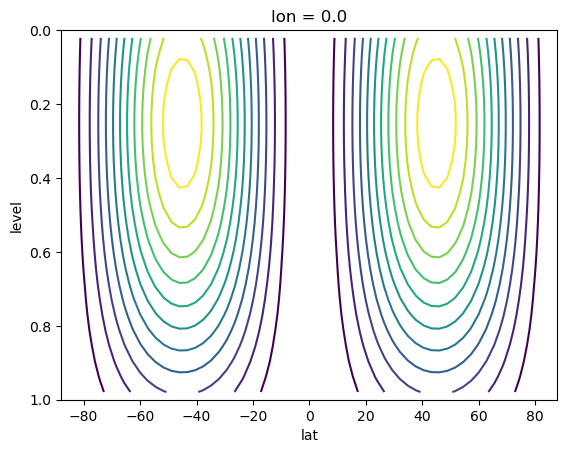

In [5]:
# Zonal wind vizualization
# 纬向风大小随高度与纬度的变化情况(经度为0), 图理解为，每个高度和纬度都有值，圆环将值相等的地方连在一起(类似等高线)
# 图里可以看出来，纬度为-60到-40，40到60时，且高度为0.4至0.2时，纬向风最大，其余纬度与高度时，纬向风比较小
# 图可以当作3D图从上边看的样子
u_array = initial_state_ds['u']
u_array_si = dimensionalize(u_array, units.m / units.s)
levels = [3 * i for i in range(1, 12)]
u_array_si.isel(lon=0).plot.contour(x='lat', y='level', levels=levels)
ax = plt.gca()
ax.set_ylim((1, 0));
plt.show()

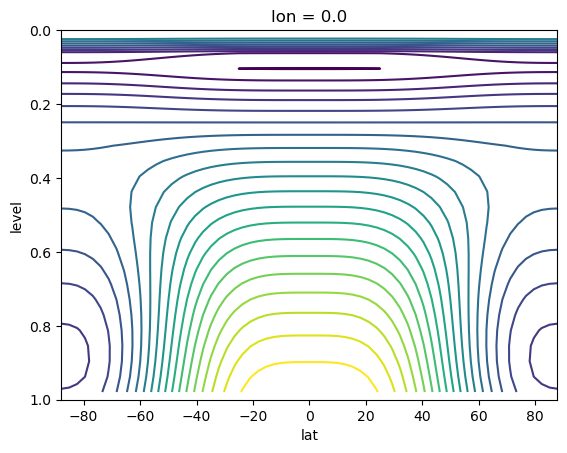

In [6]:
# Temperature vizualization
# 温度随纬度和高度的变化
t_array = initial_state_ds['temperature']  # 提取初始状态中的温度
t_array_si = dimensionalize(t_array, units.degK)  # 将温度数据的单位转换为开尔文（K）
levels = np.linspace(210, 305, 1 + (305 - 210) // 5)  # 将210到305每隔5个分一块
t_array_si.isel(lon=0).plot.contour(x='lat', y='level', levels=levels)
ax = plt.gca()
ax.set_ylim((1, 0))
plt.show()

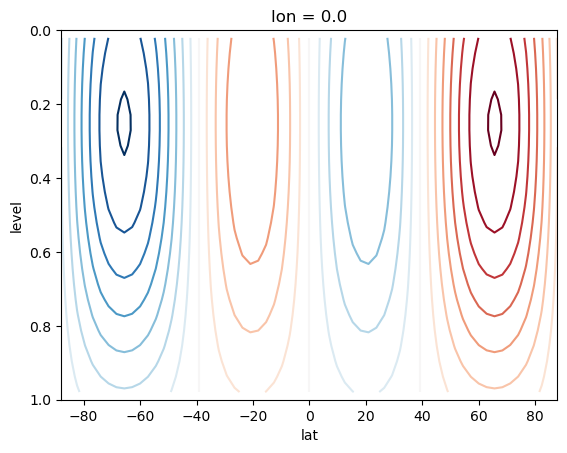

In [7]:
# Relative vorticity vizualization
# 可视化相对涡度
voriticty_array = initial_state_ds['vorticity']  # 提取温度数据
voriticty_array_si = dimensionalize(voriticty_array, 1 / units.s)  # 
levels = np.linspace(-1.75e-5, 1.75e-5, 15)
voriticty_array_si.isel(lon=0).plot.contour(x='lat', y='level', levels=levels)
ax = plt.gca()
ax.set_ylim((1, 0));
plt.show()

# Initializing the state and running a model forward

In [8]:
# Setting up primitivie equations solver
# 设置初始方程，时间步长与时间积分方式(龙格库塔)
primitive = dinosaur.primitive_equations.PrimitiveEquations(
    ref_temps, orography, coords, physics_specs)
dt_s = 100 * units.s
dt = physics_specs.nondimensionalize(dt_s)
step_fn = dinosaur.time_integration.imex_rk_sil3(primitive, dt)

## Integration of steady state in time
定义时间推进函数（直接由内循环次数和外循环次数得到最终状态）

In [9]:
# 每2小时保存一次模拟状态（save_every），并设置总模拟时间为1周（total_time）
save_every = 2 * units.hour
total_time = 1 * units.week
inner_steps = int(save_every / dt_s)  # 计算内循环次数
outer_steps = int(total_time / save_every)  # 计算外循环次数
filters = [dinosaur.time_integration.exponential_step_filter(grid, dt),]
step_fn = dinosaur.time_integration.step_with_filters(step_fn, filters)
integrate_fn = dinosaur.time_integration.trajectory_from_step(
    step_fn, outer_steps, inner_steps)
integrate_fn = jax.jit(integrate_fn)  # jax.jit对integrate_fn进行了JIT编译。JIT编译可以显著提高函数的执行速度，特别是在涉及大量数值计算时

## 进行稳态的时间推进

In [10]:
# Running integration starting with steady state
# 由初始状态进行时间推进
%time final, trajectory = jax.block_until_ready(integrate_fn(steady_state))

CPU times: user 8.94 s, sys: 12.6 s, total: 21.5 s
Wall time: 5.96 s


In [11]:
# Constructing predictions and diagnostics
# 读取计算结果trajectory中的各个变量， 流程是转换成各种形式，最后到能读的形式trajectory_ds
# trajectory_ds里边有涡度，地表压力，温度
trajectory = jax.device_get(trajectory)
times = save_every * np.arange(outer_steps)

trajectory_dict, _ = dinosaur.pytree_utils.as_dict(trajectory)
u, v = dinosaur.spherical_harmonic.vor_div_to_uv_nodal(
    grid, trajectory.vorticity, trajectory.divergence)
trajectory_dict.update({'u': u, 'v': v})
nodal_trajectory_fields = dinosaur.coordinate_systems.maybe_to_nodal(
    trajectory_dict, coords=coords)
trajectory_ds = dinosaur.xarray_utils.data_to_xarray(
    nodal_trajectory_fields, coords=coords, times=times)

trajectory_ds['surface_pressure'] = np.exp(trajectory_ds.log_surface_pressure[:, 0, :,:])
temperature = dinosaur.xarray_utils.temperature_variation_to_absolute(
    trajectory_ds.temperature_variation.data, ref_temps)
trajectory_ds = trajectory_ds.assign(  # trajectory_ds
    temperature=(trajectory_ds.temperature_variation.dims, temperature))

 First we verify that the steady state is indeed stationary (i.e. no apparent changes over the course of 7-day integration)

## 接下来用算出的变量，重复
1. 读变量，
2. 换单位
3. 画图

### Vorticity dynamics

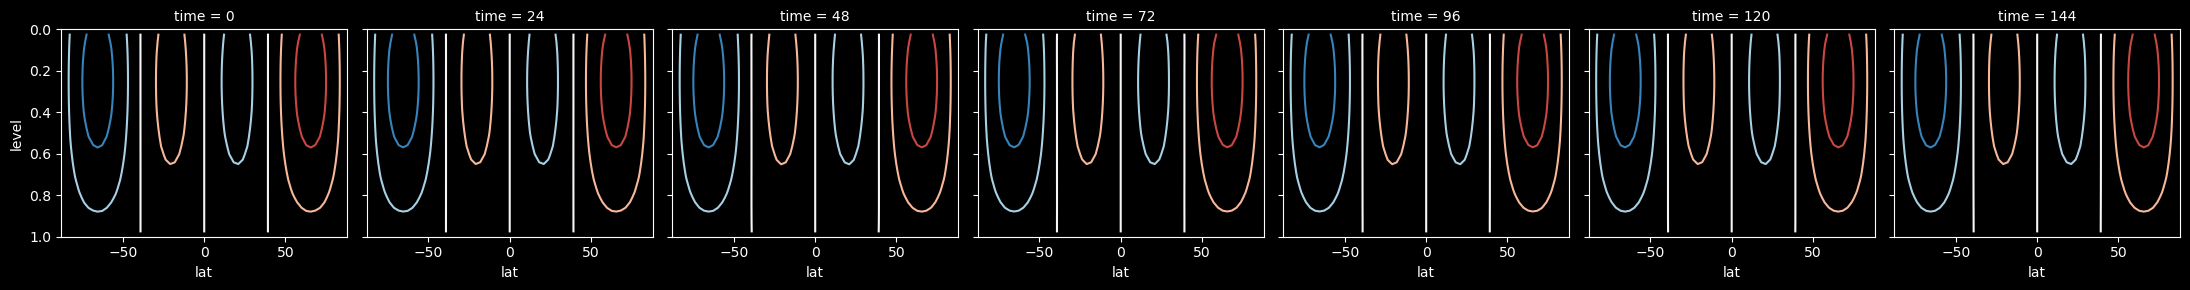

In [17]:
data_array = trajectory_ds['vorticity']

data_array.isel(lon=0).thin(time=12).plot.contour(x='lat', y='level', col='time')
ax = plt.gca()
ax.set_ylim((1, 0))
plt.show()

### Pressure dynamics

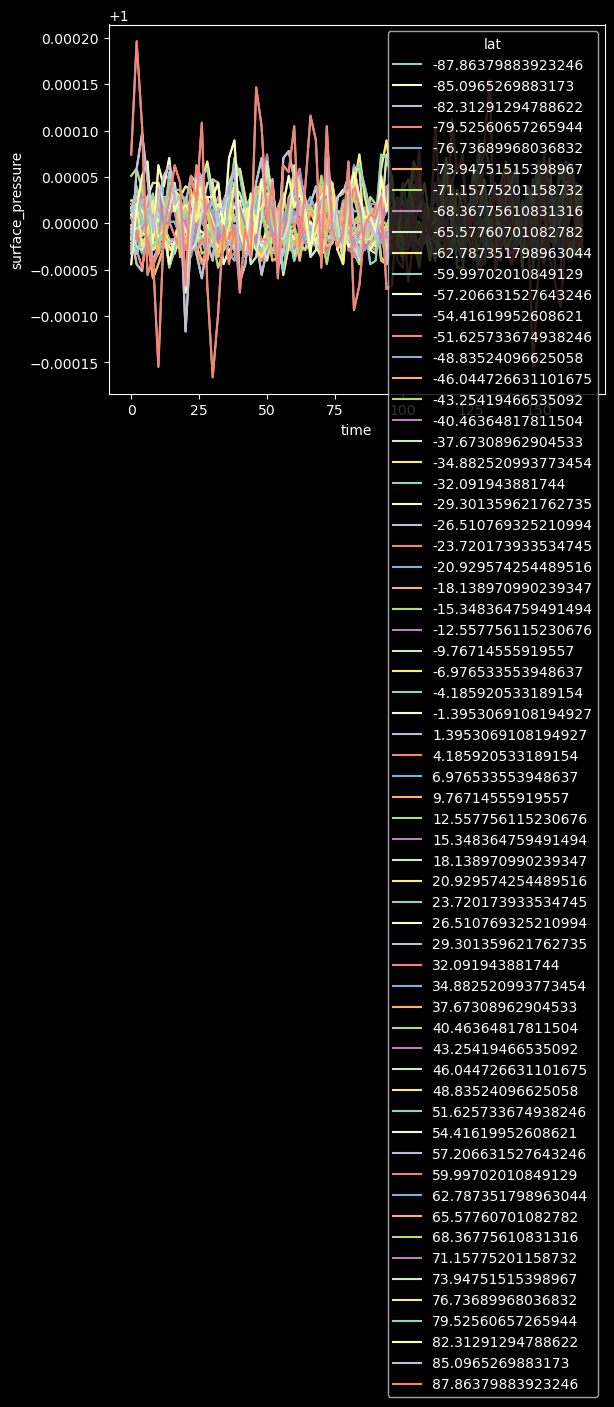

/tmp/ipykernel_3933081/1659706978.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend().remove()


In [19]:
# normalized surface pressure should remain roughly constant
# 不同纬度的压力随时间的变化的图
data_array = (trajectory_ds['surface_pressure'] /
              physics_specs.nondimensionalize(1e5 * units.pascal))
data_array.max(['lon']).plot(x='time', hue='lat')
ax = plt.gca()
plt.show()
ax.legend().remove()


### Temperature dynamics

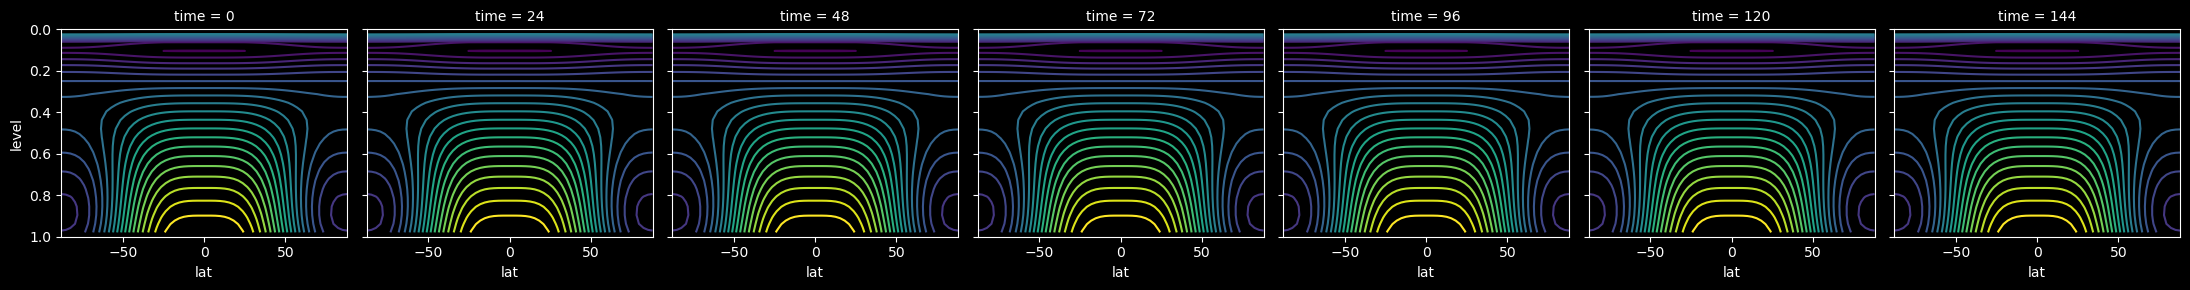

In [20]:
# 绘制不同时间的   温度随纬度和高度的变化图
t_array = trajectory_ds['temperature']
t_array_si = dimensionalize(t_array, units.degK)
levels = np.linspace(210, 305, 1 + (305 - 210) // 5)
t_array_si.isel(lon=0).thin(time=12).plot.contour(
    x='lat', y='level', levels=levels, col='time')
ax = plt.gca()
ax.set_ylim((1, 0));
plt.show()

### Divergence

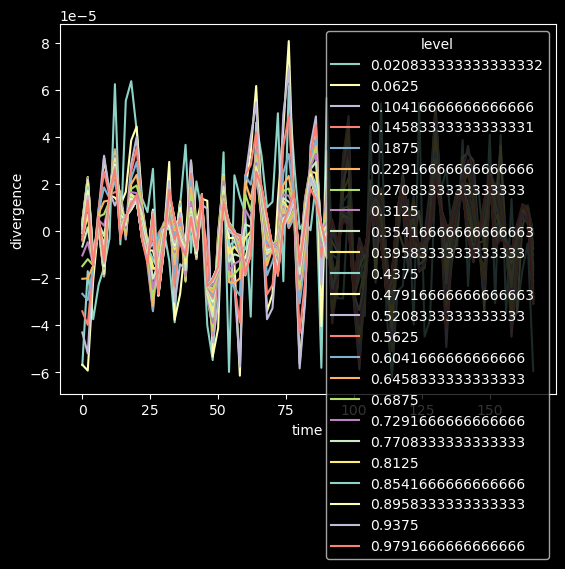

/tmp/ipykernel_3933081/871766033.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend().remove();


In [21]:
# Divergence is expected to be very close to 0 throughout
# 绘制不同高度(导致图中不同的线)的 散度随时间变化的图
data_array = trajectory_ds['divergence']
data_array.mean(['lat', 'lon']).plot(x='time', hue='level')
ax = plt.gca()
plt.show()
ax.legend().remove();


# Initiating instability
# 进行非稳态的时间推进

In this stage we add a prescribed perturbation to the steady state and observe the evolution of baroclinic instability

In [22]:
perturbation = dinosaur.primitive_equations_states.baroclinic_perturbation_jw(  # 定义扰动
    coords, physics_specs)
state = steady_state + perturbation  # 定义非稳态 = 稳态 + 扰动

In [23]:
# 定义时间推进时的内外循环次数
save_every = 2 * units.hour
total_time = 2 * units.week
inner_steps = int(save_every / dt_s)
outer_steps = int(total_time / save_every)
integrate_fn = dinosaur.time_integration.trajectory_from_step(
    step_fn, outer_steps, inner_steps)
integrate_fn = jax.jit(integrate_fn)

In [24]:
# 进行时间推进
%time final, trajectory = jax.block_until_ready(integrate_fn(state))

CPU times: user 56min 24s, sys: 3min 41s, total: 1h 6s
Wall time: 19min 24s


In [29]:
# 将计算结果进行各种格式转换，最终转换为trajectory_ds，其里边有地表压力，温度和速度
# formatting predictions to xarray.Dataset for ease of vizualization
trajectory = jax.device_get(trajectory)
times = (save_every * np.arange(outer_steps)).to(units.s)

trajectory_dict, _ = dinosaur.pytree_utils.as_dict(trajectory)
u, v = dinosaur.spherical_harmonic.vor_div_to_uv_nodal(
    grid, trajectory.vorticity, trajectory.divergence)
trajectory_dict.update({'u': u, 'v': v})
nodal_trajectory_fields = dinosaur.coordinate_systems.maybe_to_nodal(
    trajectory_dict, coords=coords)
trajectory_ds = dinosaur.xarray_utils.data_to_xarray(
    nodal_trajectory_fields, coords=coords, times=times)

trajectory_ds['surface_pressure'] = np.exp(trajectory_ds.log_surface_pressure[:, 0, :,:])
temperature = dinosaur.xarray_utils.temperature_variation_to_absolute(
    trajectory_ds.temperature_variation.data, ref_temps)
trajectory_ds = trajectory_ds.assign(
    temperature=(trajectory_ds.temperature_variation.dims, temperature))

/home/zhangjing/anaconda3/envs/JAX/lib/python3.10/site-packages/xarray/core/indexes.py:190: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  index = pd.Index(np.asarray(array), **kwargs)


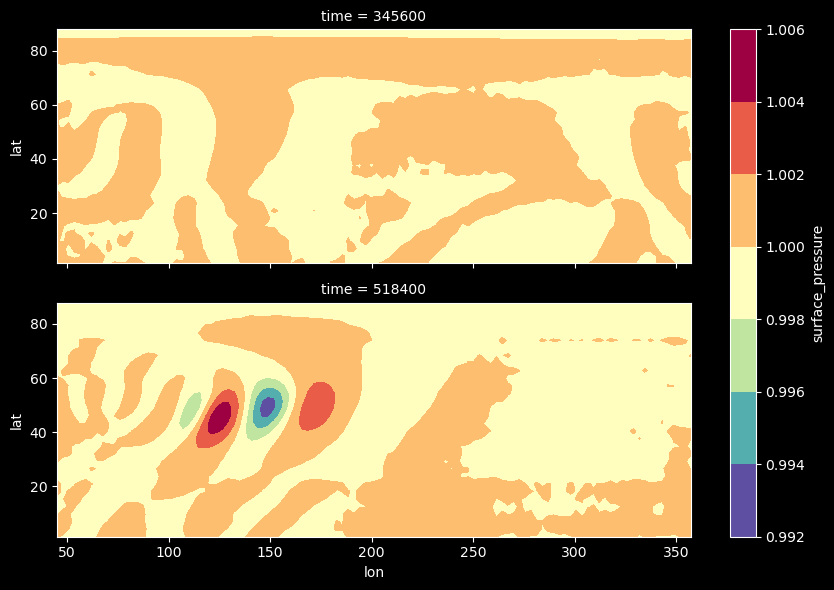

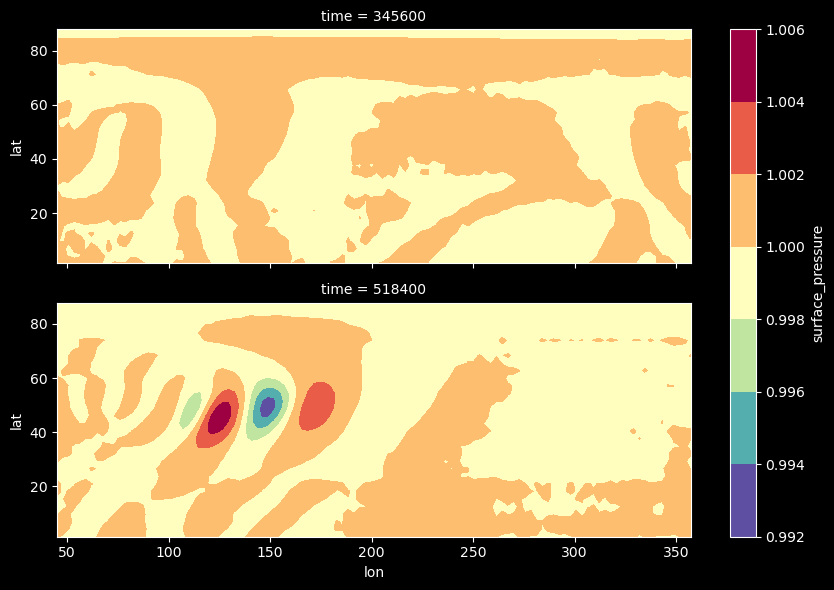

In [31]:
# 读变量，定义坐标系，最后画图
# Contour plots of log-surface pressure at 4/6 days

data_array = (trajectory_ds['surface_pressure'] /
              physics_specs.nondimensionalize(1e5 * units.pascal))
levels = [(992 + 2 * i) / 1000 for i in range(8)]

data_array.sel(
    {'lat': slice(0, 90),
     'lon': slice(45, 360),
     'time': [(4 * units.day).to(units.s).m,
               (6 * units.day).to(units.s).m],}
     ).plot.contourf(
         x='lon', y='lat', row='time', levels=levels, cmap=plt.cm.Spectral_r)

fig = plt.gcf()
fig.set_figwidth(10)
plt.show()

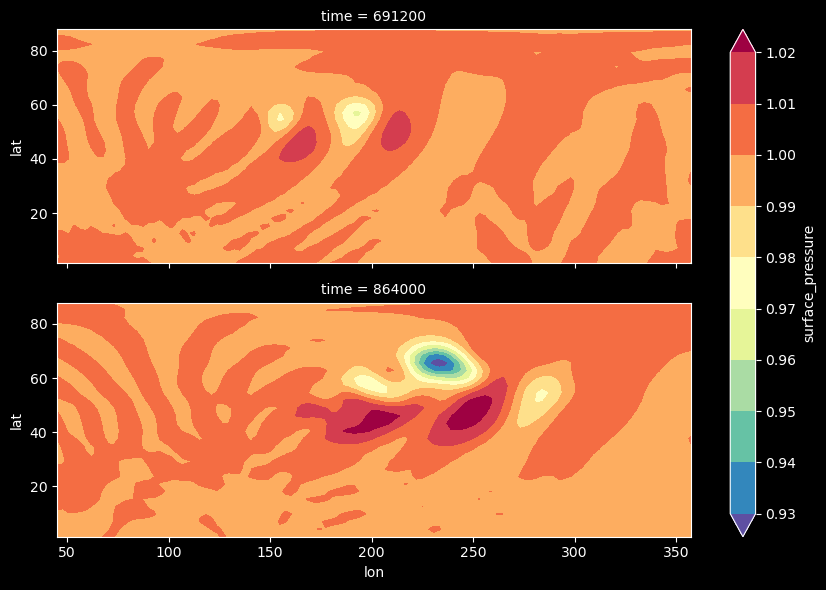

In [32]:
# 读取变量(地表压力)，定义坐标系，最后画图, 时间更往后
# Contour plots of log-surface pressure at 8 and 10 days
data_array = (trajectory_ds['surface_pressure'] /
              physics_specs.nondimensionalize(1e5 * units.pascal))
levels = [(930 + 10 * i) / 1000 for i in range(10)]

(data_array.sel({'lat': slice(0, 90),
                 'lon': slice(45, 360),
                 'time': [(8 * units.day).to(units.s).m,
                           (10 * units.day).to(units.s).m]})
           .plot.contourf(x='lon',
                          y='lat',
                          row='time',
                          levels=levels,
                          cmap=plt.cm.Spectral_r))

fig = plt.gcf()
fig.set_figwidth(10)
plt.show()

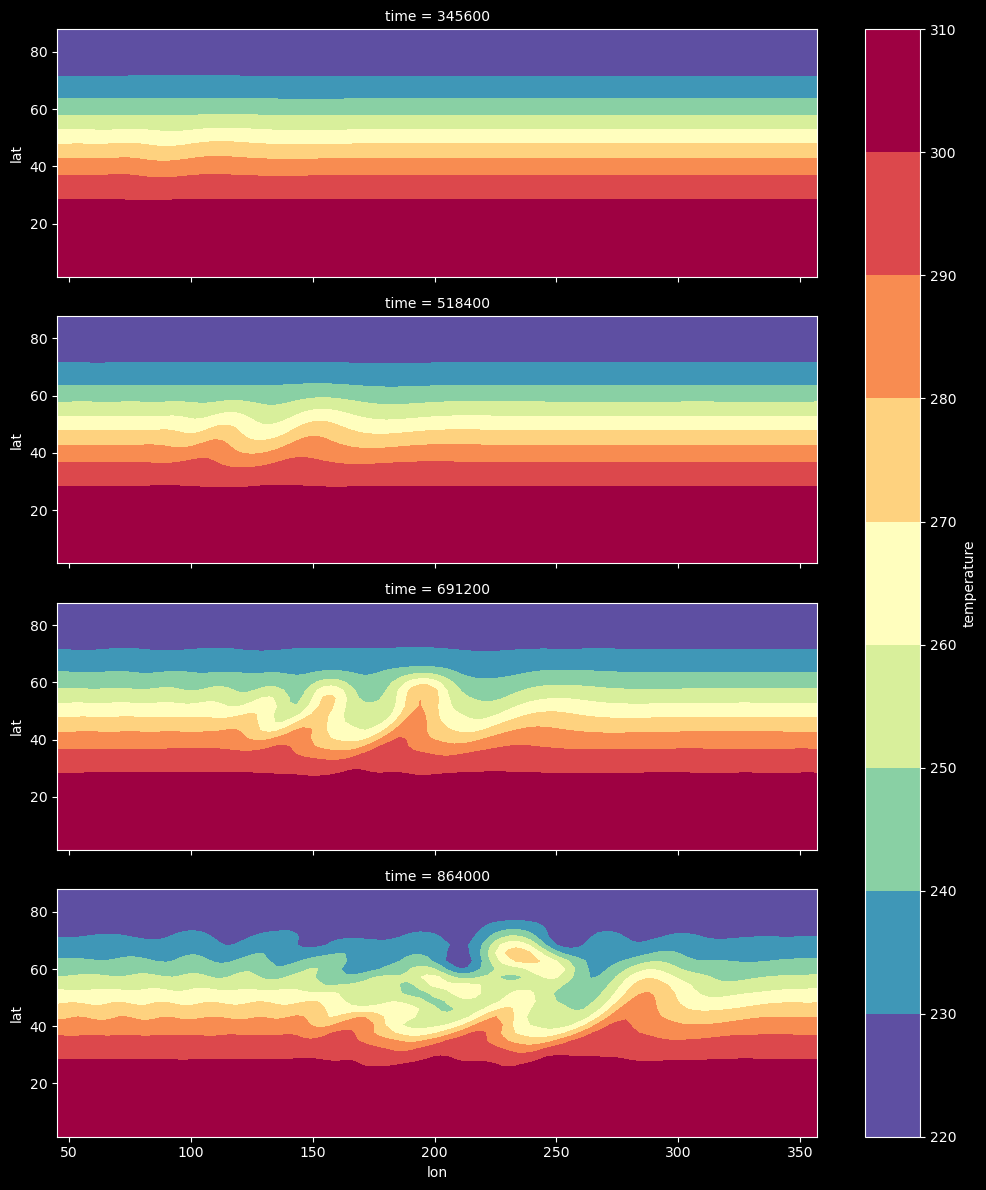

In [33]:
# Temperature at days 4, 6, 8, 10 (note we do not interpolate to exactly 850hPa)
# 横坐标为lon，纵坐标为lat, 不同的图代表不同的时间，不同的颜色代表温度的不同的值
temp_array = trajectory_ds['temperature']
levels = [(220 + 10 * i) for i in range(10)]
target_pressure = 0.85 * physics_specs.nondimensionalize(1e5 * units.pascal)  # TODO: add interpolation

(temp_array.sel({'lat': slice(0, 90),
                 'lon': slice(45, 360),
                 'time': [(4 * units.day).to(units.s).m,
                           (6 * units.day).to(units.s).m,
                           (8 * units.day).to(units.s).m,
                           (10 * units.day).to(units.s).m]})
           .isel(level=22)
           .plot.contourf(x='lon',
                          y='lat',
                          row='time',
                          levels=levels,
                          cmap=plt.cm.Spectral_r))
fig = plt.gcf()
fig.set_figwidth(12)
plt.show()

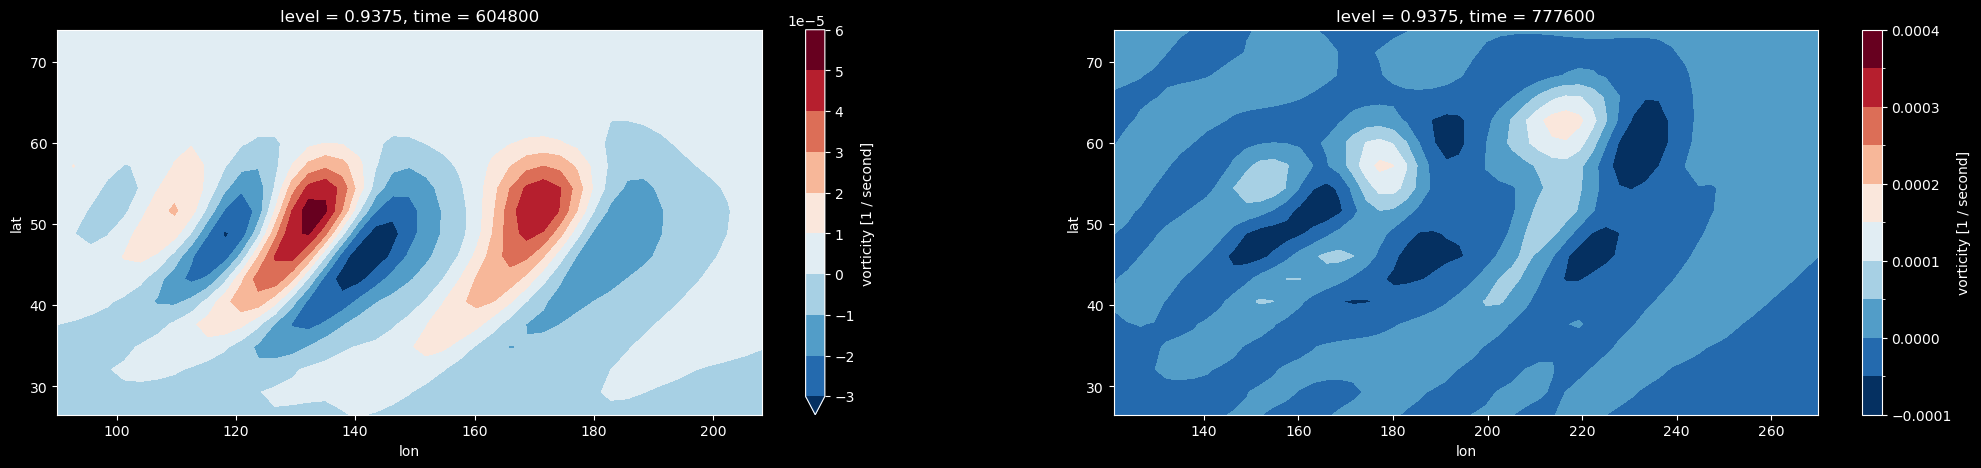

In [34]:
# Vorticity features
# 横坐标为lon，纵坐标为lat, 不同的图代表不同的时间和高度，不同的颜色代表涡度的不同的值
voriticty_array = trajectory_ds['vorticity']
target_pressure = 0.85 * physics_specs.nondimensionalize(1e5 * units.pascal)  # TODO: add interpolation
voriticty_array_si = dimensionalize(voriticty_array, 1/ units.s)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 5))

levels = [-3e-5 + 1e-5 * i for i in range(10)]
(voriticty_array_si.sel({'lat': slice(25, 75),
                         'lon': slice(90, 210),
                         'time': (7 * units.day).to(units.s).m})
                   .isel(level=22)
                   .plot.contourf(x='lon',
                                  y='lat',
                                  levels=levels,
                                  ax=ax1))

levels = [-10e-5 + 5e-5 * i for i in range(11)]
(voriticty_array_si.sel({'lat': slice(25, 75),
                         'lon': slice(120, 270),
                         'time': (9 * units.day).to(units.s).m})
                   .isel(level=22)
                   .plot.contourf(x='lon',
                                  y='lat',
                                  levels=levels,
                                  ax=ax2))
fig.set_figwidth(25)
plt.show()

/home/zhangjing/anaconda3/envs/JAX/lib/python3.10/site-packages/numpy/core/numerictypes.py:511: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  cast[key] = lambda x, k=key: array(x, copy=False).astype(k)


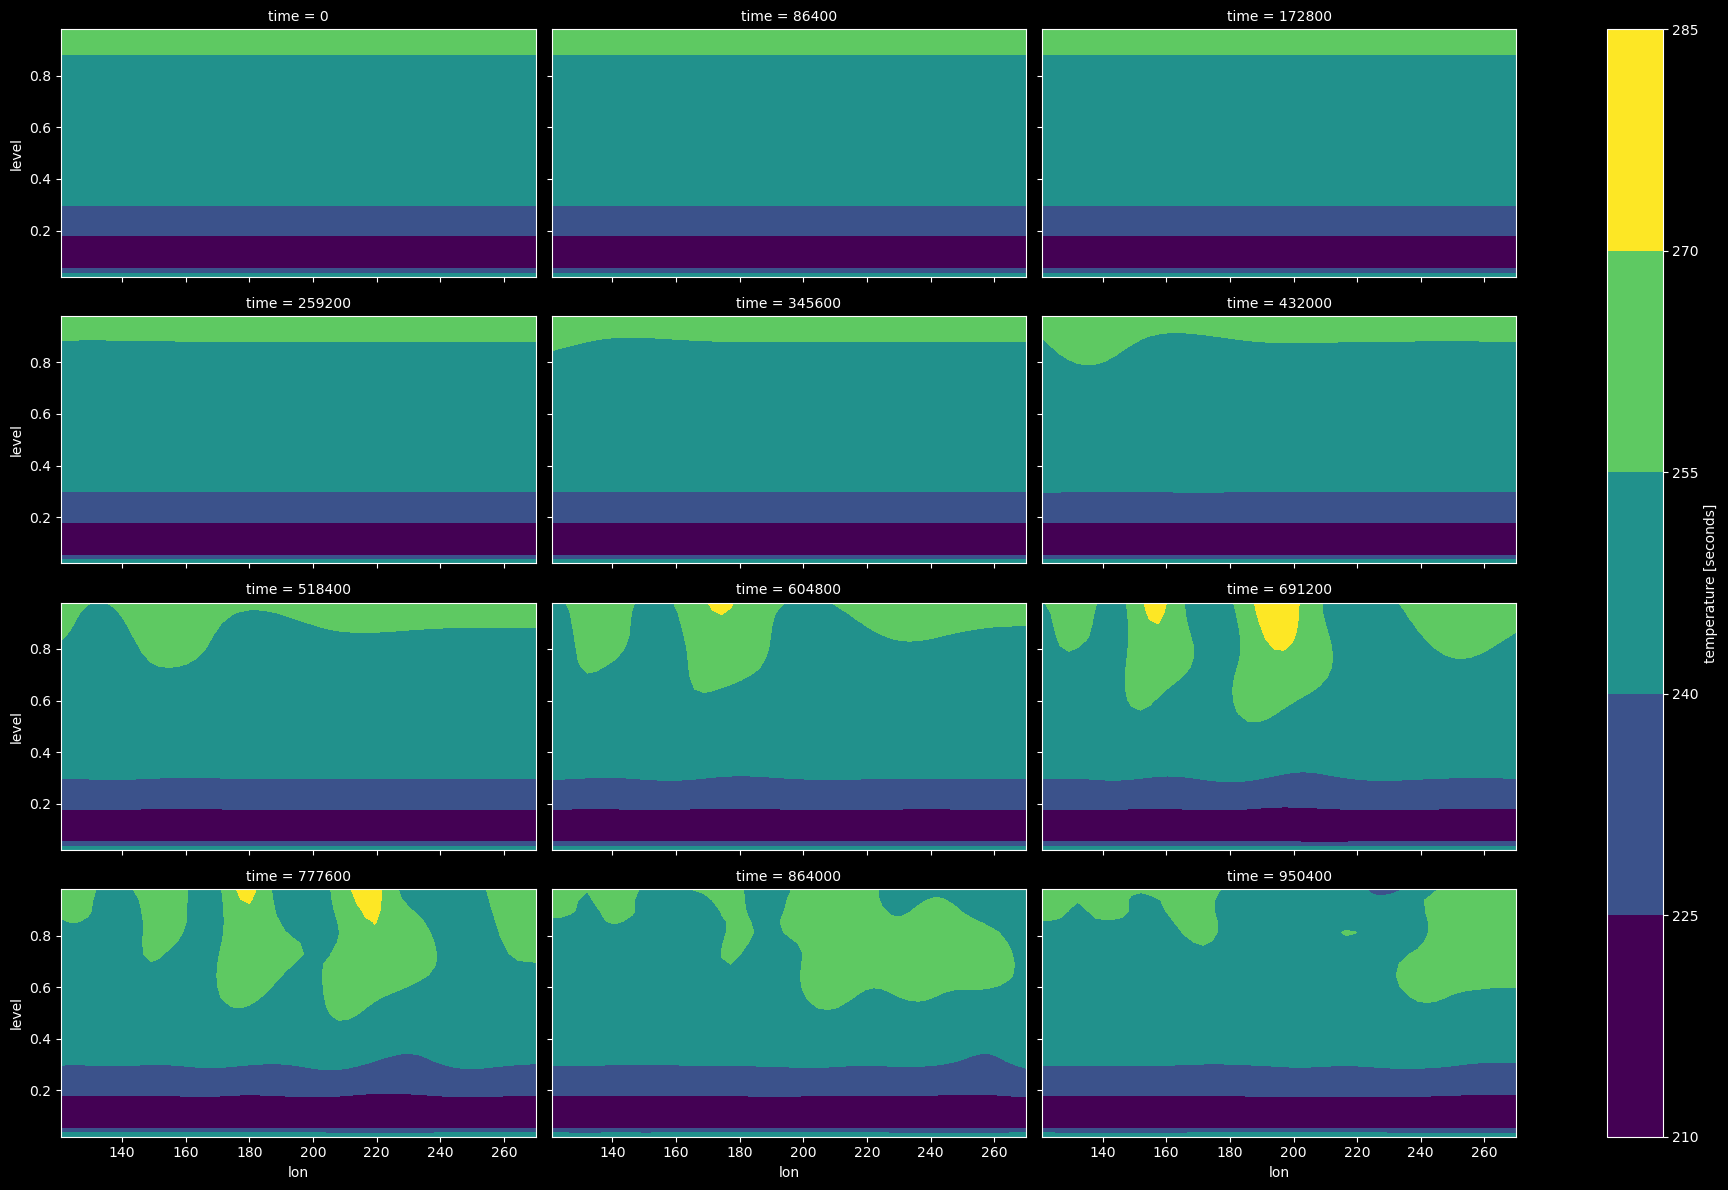

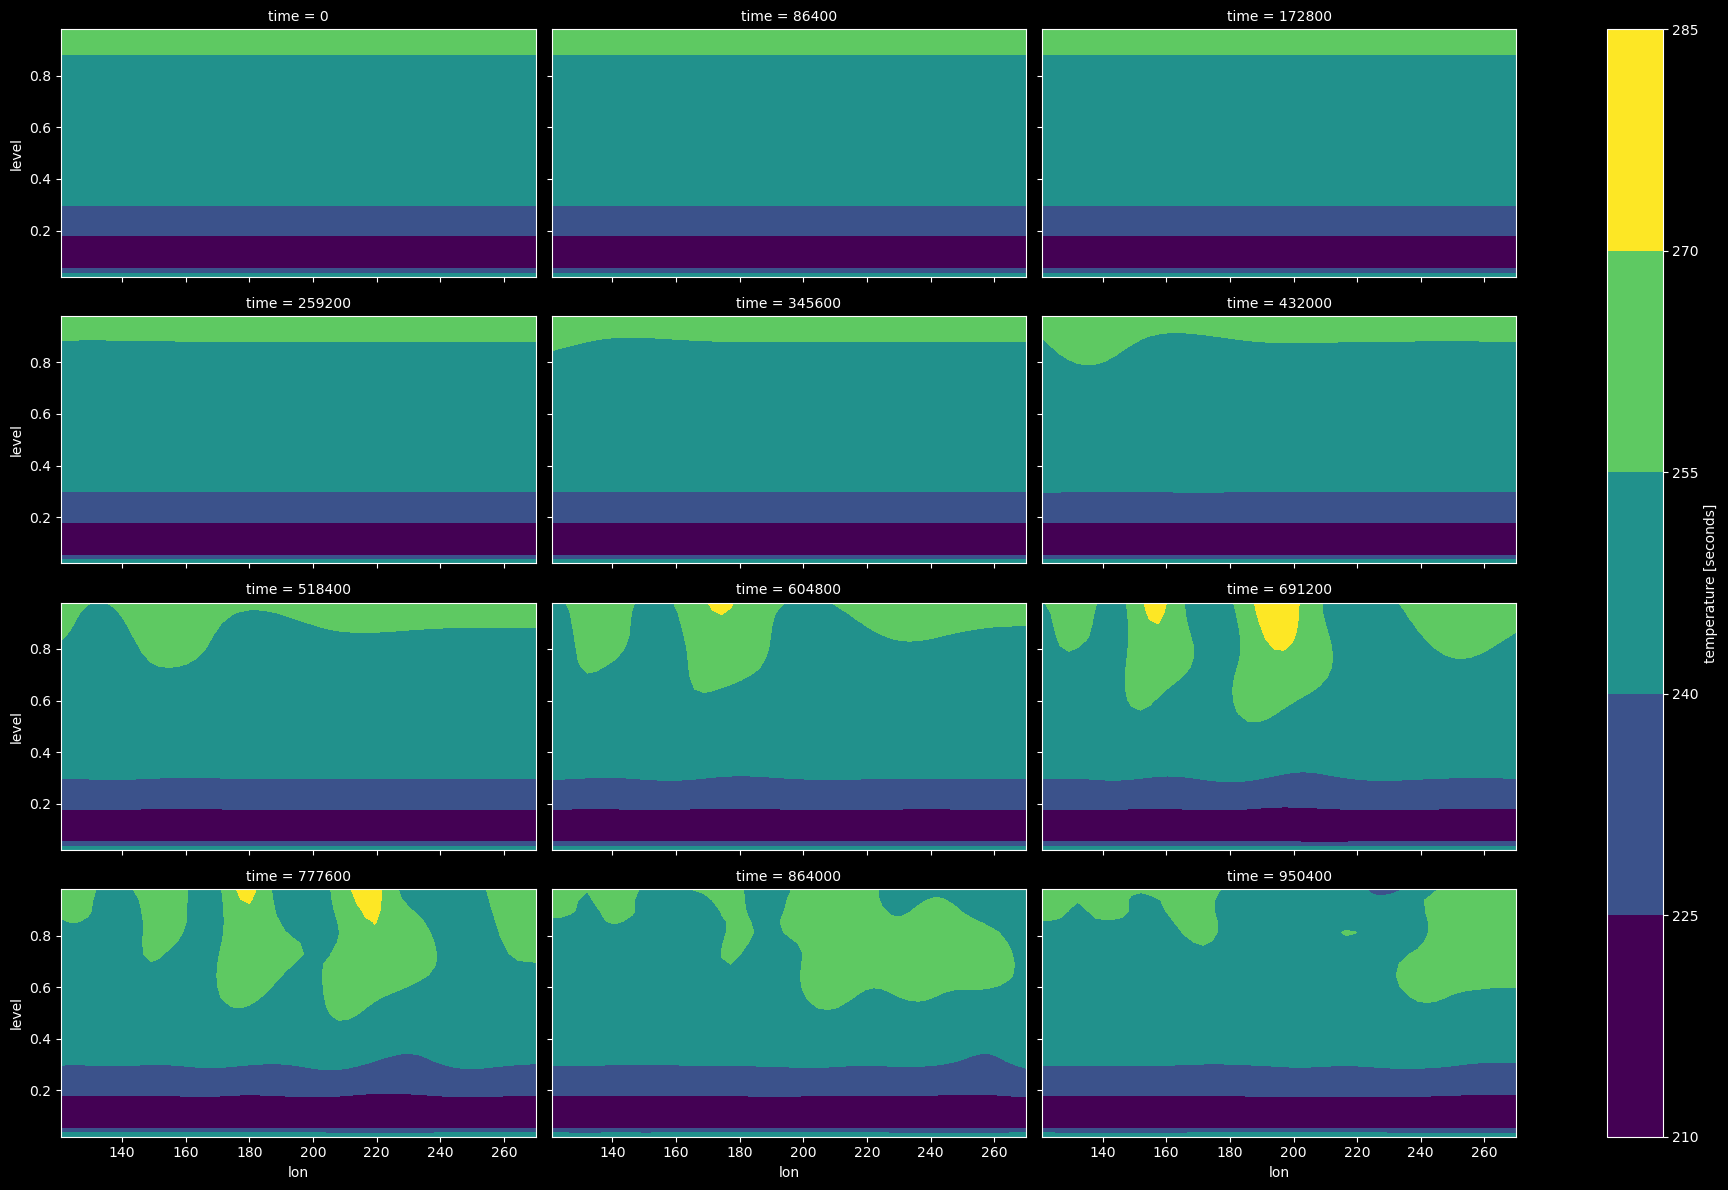

In [36]:
# Daily vertical slices of temperature.
# 横坐标为lon，纵坐标为高度, 不同的图代表不同的时间，不同的颜色代表涡度的不同的温度的值
times = np.cast[np.int32]((np.arange(12) * units.day).to(units.second))
data = (temp_array.sel(lat=slice(54, 56),
                lon=slice(120, 270),
                time=times)
            .isel(lat=0))
data.attrs['units'] = 'seconds'
data.plot.contourf(x='lon', y='level', row='time',
                           aspect=2, col_wrap=3);
plt.show()